## Install all the Dependencies
Fastest Demucs - mdx_extra_q

In [1]:
!pip install demucs
!pip install -q diffq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 56.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.1/87.1 kB 10.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.3/249.3 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 9.2 MB/s eta 0:00:00
  Created wheel for demucs: filename=demucs-4.0.1-py3-none-any.whl size=78388 sha256=bf09472f85e4aa5511bf34ea256d08e4ce0820d6ae09feb1a92764fe5619efd3
  Stored in directory: /root/.cache/pip/wheels/1b/0c/20/a3b3daa1f9b65c8b0445729f94740ec335d0f86f1066c5c414
  Created wheel for julius: filename=julius-0.2.7

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.image import resize
import subprocess
import os
import sys
# from spleeter.separator import Separator
import librosa

# Save the Model in you google drive
## Mount the google drive to use as a local disk

download the model file from the github
https://github.com/DevBySuraj/Indian_Music_Genre_Classifier

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load the Model

Total params: 506,885 Trainable params: 505,093 Non-trainable params: 1,792

Training Time: ~40-50 mins (on RTX 3050)

Accuracy: 97.06%


In [4]:
model = tf.keras.models.load_model("/content/drive/MyDrive/Colab Notebooks/Indian_Music_Genre_Classifier/Multi_input_CNN_v2.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


# Run all the required functions



## 1. Demucs Function
this function separates the uploaded into four parts
1. Vocals
2. Bass
3. Drums
4. Other

In [5]:
import os
import torch
from demucs.pretrained import get_model
from demucs.apply import apply_model
import torchaudio

def demucs_conversion(input_path, output_path):
    base_filename = os.path.splitext(os.path.basename(input_path))[0]

    try:
        print(f"--- 🚀 Separating: {base_filename} ---")

        # ⚡ Fastest model
        model = get_model('mdx_extra_q')
        model.eval()
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f"  🖥️ Using: {device.upper()}")
        model.to(device)

        # Load audio
        wav, sr = torchaudio.load(input_path)
        wav = wav.to(device)

        # Resample if needed
        if sr != model.samplerate:
            wav = torchaudio.functional.resample(wav, sr, model.samplerate)

        # Add batch dimension
        wav = wav.unsqueeze(0)

        # Separate
        with torch.no_grad():
            sources = apply_model(model, wav)

        # Save stems
        final_stem_path = os.path.join(output_path, 'mdx_extra_q', base_filename)
        os.makedirs(final_stem_path, exist_ok=True)

        for i, source in enumerate(model.sources):
            stem_path = os.path.join(final_stem_path, f"{source}.wav")
            torchaudio.save(stem_path, sources[0][i].cpu(), model.samplerate)
            print(f"  💾 Saved: {source}.wav")

        print(f"✅ Success! Path: {final_stem_path}")
        return final_stem_path

    except Exception as e:
        print(f"❌ Demucs failed: {e}")
        return None

## 2. Data Preprocessing Function or Chunking Function
This function takes the song folder as input where all four stem(vocal, drum, bass and other are stored) and divided into 4 second chunks, converts into melspectrogram and saves them in a list

In [6]:
def chunking(song_folder_path, sample_set_rate = 22050, target_shape = (150,150), threshold = 0.01 ):
    # Lists for each stem
    v_data, d_data, b_data, o_data = [], [], [], [] ##will store all the spectrogram data
    X_test = []
    if not os.path.isdir(song_folder_path):
        return
    try:
        # 1. LOAD ALL 4 STEMS SIMULTANEOUSLY
        # We use fixed sr to ensure they all have the same length
        v_audio, _ = librosa.load(os.path.join(song_folder_path, 'vocals.wav'), sr=sample_set_rate)
        d_audio, _ = librosa.load(os.path.join(song_folder_path, 'drums.wav'), sr=sample_set_rate)
        b_audio, _ = librosa.load(os.path.join(song_folder_path, 'bass.wav'), sr=sample_set_rate)
        o_audio, _ = librosa.load(os.path.join(song_folder_path, 'other.wav'), sr=sample_set_rate)

        sample_rate = sample_set_rate #function sample rate, common for all
    except Exception as e:
        print(f"Skipping due to missing/corrupt stems: {e}")
        return

    # 2. SLIDING WINDOW SETUP
    chunk_duration = 4
    overlap_duration = 2
    chunk_samples = int(chunk_duration * sample_rate)
    stride = int((chunk_duration - overlap_duration) * sample_rate)

    # 3. SYNCHRONIZED CLIPPING
    # We loop based on the length of the audio
    for start in range(0, len(o_audio) - chunk_samples + 1, stride):
        end = start + chunk_samples

        # Extract chunks from ALL stems using the SAME start/end
        v_chunk = v_audio[start:end]
        d_chunk = d_audio[start:end]
        b_chunk = b_audio[start:end]
        o_chunk = o_audio[start:end]

        # 4. MASTER THRESHOLD CHECK (Based on 'Other' stem)
        rms_other = np.sqrt(np.mean(o_chunk**2))

        if rms_other > threshold:
            # Process each chunk into a Mel-Spectrogram
            for chunk, target_list in zip([v_chunk, d_chunk, b_chunk, o_chunk], #v_chunk is a chunk not list
                                            [v_data, d_data, b_data, o_data]): #but v_data is list where we append v_chunk

                mel = librosa.feature.melspectrogram(y=chunk, sr=sample_rate, n_mels=150)
                mel_db = librosa.power_to_db(mel, ref=np.max)

                # Resize and convert to NumPy
                mel_resized = resize(np.expand_dims(mel_db, axis=-1), target_shape).numpy()
                target_list.append(mel_resized)

    X_test = [np.array(v_data), np.array(d_data), np.array(b_data), np.array(o_data)]
    # Apply to your split data
    X_test  = normalize_stems(X_test)
    X_test  = [s.astype('float32') for s in X_test]
    return X_test


## 3. Normalization
This function normalized the X_test in a range from 0 to 1(the input which we will give to the model)

In [7]:
def normalize_stems(stem_list):
    normalized_list = []
    for stem_array in stem_list:
        # Get min and max for this specific stem batch
        min_val = np.min(stem_array)
        max_val = np.max(stem_array)

        # Scale to 0-1 range
        # Formula: (x - min) / (max - min)
        normalized_stem = (stem_array - min_val) / (max_val - min_val)
        normalized_list.append(normalized_stem)

    return normalized_list

## 4. Classes or Genres

In [8]:
classes = ['bollypop', 'carnatic', 'ghazal', 'semiclassical', 'sufi']

## 5. Model Prediction Function

In [9]:
def model_prediction(X_test):
    y_pred = model.predict(X_test)
    predicted_categories = np.argmax(y_pred, axis = 1)
    unique_elements, counts = np.unique(predicted_categories, return_counts = True)
    max_count = np.max(counts)
    index = unique_elements[counts == max_count][0]
    return classes[index]

# Input Path
here give the path of audio which you want to test

# Output Path
here give the path where all files after separation will be saved

# Direct Play

In [10]:
input_path = "/content/drive/MyDrive/Colab Notebooks/Indian_Music_Genre_Classifier/genrenew/bollypop/bp08.mp3"
output_path = "/content/drive/MyDrive/Colab Notebooks/Indian_Music_Genre_Classifier/test_output"

## Now Using all function to Test the Model

#### 1. Demucs Separate Function
separates the audio into four parts

In [12]:
song_folder_path = demucs_conversion(input_path, output_path)

--- 🚀 Separating: bp08 ---
Downloading: "https://dl.fbaipublicfiles.com/demucs/mdx_final/83fc094f-4a16d450.th" to /root/.cache/torch/hub/checkpoints/83fc094f-4a16d450.th


100%|██████████| 48.4M/48.4M [00:00<00:00, 88.4MB/s]


Downloading: "https://dl.fbaipublicfiles.com/demucs/mdx_final/464b36d7-e5a9386e.th" to /root/.cache/torch/hub/checkpoints/464b36d7-e5a9386e.th


100%|██████████| 37.1M/37.1M [00:00<00:00, 91.5MB/s]


Downloading: "https://dl.fbaipublicfiles.com/demucs/mdx_final/14fc6a69-a89dd0ee.th" to /root/.cache/torch/hub/checkpoints/14fc6a69-a89dd0ee.th


100%|██████████| 36.7M/36.7M [00:00<00:00, 169MB/s]


Downloading: "https://dl.fbaipublicfiles.com/demucs/mdx_final/7fd6ef75-a905dd85.th" to /root/.cache/torch/hub/checkpoints/7fd6ef75-a905dd85.th


100%|██████████| 37.6M/37.6M [00:00<00:00, 160MB/s]


  🖥️ Using: CUDA
  💾 Saved: drums.wav
  💾 Saved: bass.wav
  💾 Saved: other.wav
  💾 Saved: vocals.wav
✅ Success! Path: /content/drive/MyDrive/Colab Notebooks/Indian_Music_Genre_Classifier/test_output/mdx_extra_q/bp08


#### Chunking
This function takes the song folder as input where all four stem(vocal, drum, bass and other are stored) and divided into 4 second chunks, converts into melspectrogram and saves them in a list


In [13]:
X_test = chunking(song_folder_path= song_folder_path)

In [14]:
print(X_test[0].shape) # shape of vocal  # Xtest list of 4 stems each of 20% of total
print(X_test[1].shape) # shape of drums
print(X_test[2].shape) # shape of bass
print(X_test[3].shape) # shape of other

(21, 150, 150, 1)
(21, 150, 150, 1)
(21, 150, 150, 1)
(21, 150, 150, 1)


#### Predicting the output by using the model

In [15]:
print(model_prediction(X_test))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
bollypop


# Below is the Architecture of the Model

##  Model Architecture Visualization

by Pydot python library and Graphiviz(windows exe and path added to users)

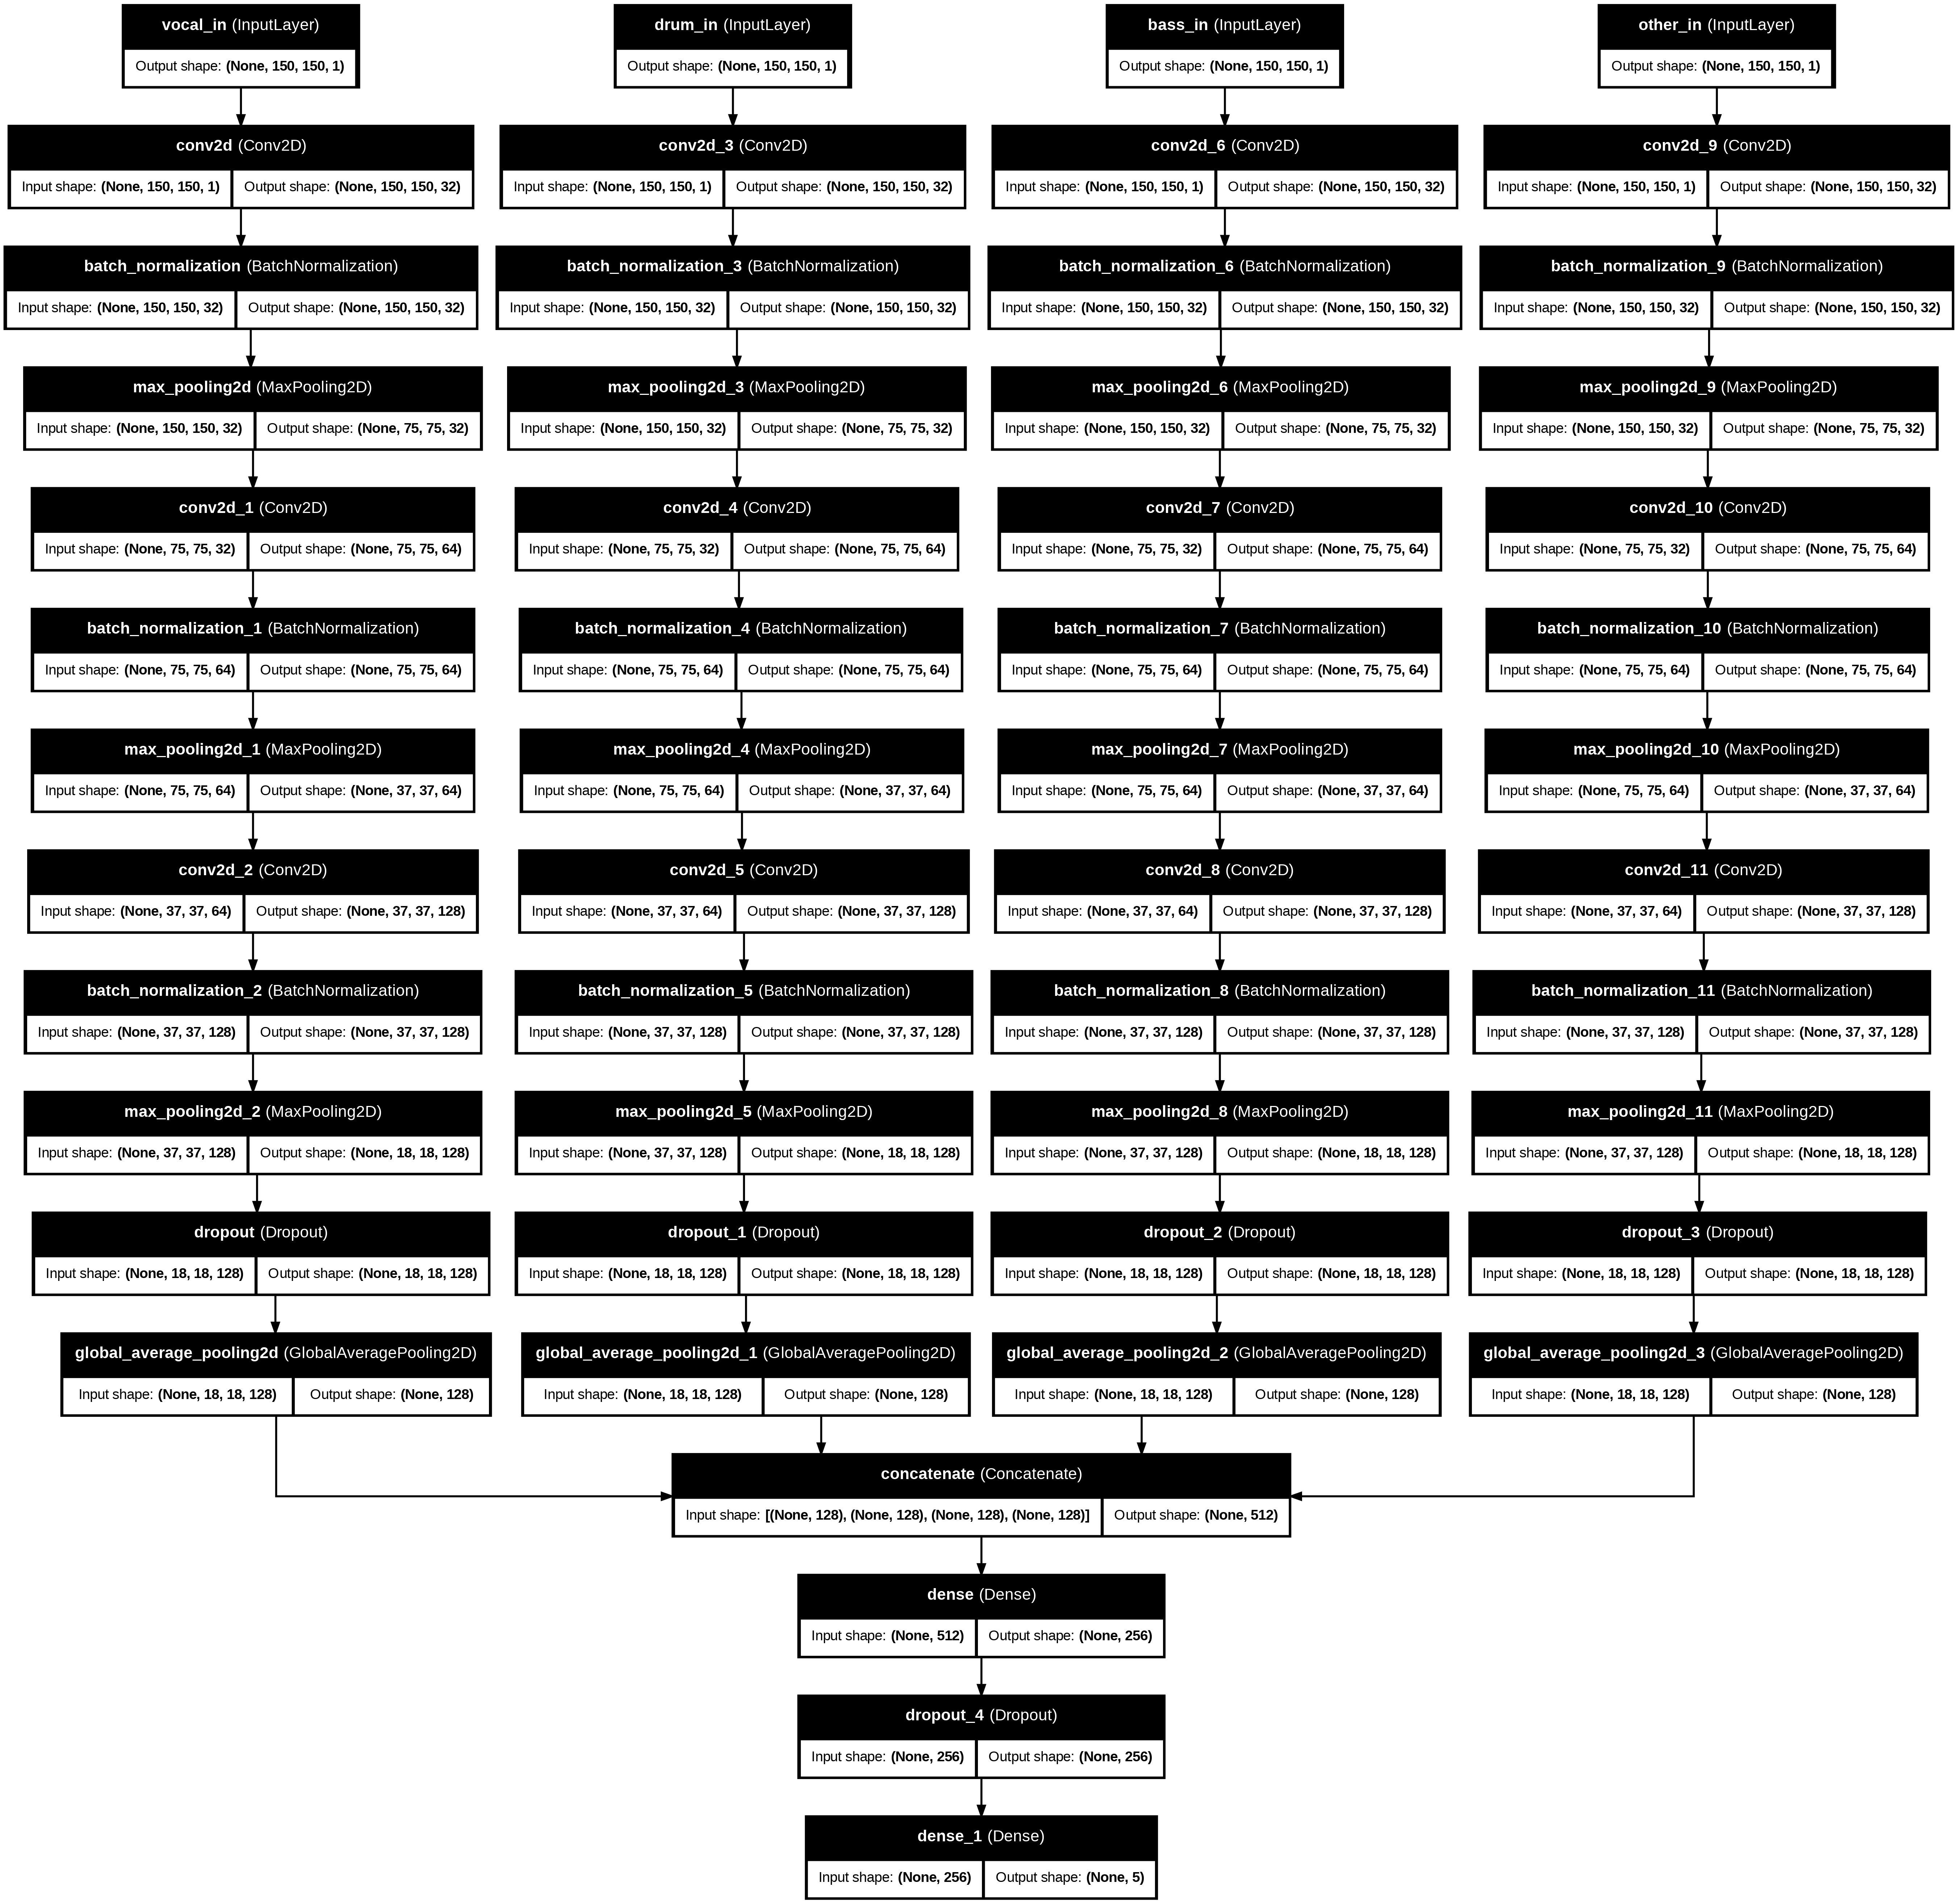

In [16]:
# Run this to save a high-quality image of your model's structure
tf.keras.utils.plot_model(
    model,
    to_file='model_architecture.png',
    show_shapes=True,
    show_layer_names=True
)

## Important Features

Total params: 506,885
Trainable params: 505,093
Non-trainable params: 1,792

Training Time: ~40-50 mins (on RTX 3050)

Validation Accuracy: 97.06%

## Future Improvements

Every great AI project ends with ideas for version 2.0. Since you hit such high accuracy, your next steps could be:

Real-time Streamer: Detecting genres from a live microphone feed.

Mood Detection: Adding a second output to predict if the song is "Happy," "Sad," or "Devotional."

Instrument Identification: Predicting which specific instrument (Sitar vs. Veena) is dominant in the "Other" stem.